# What does the metacells for combined envi latent look like ?

In [105]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells 
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad


## Reading the anndata objects

In [106]:
sc_ad=sc.read_h5ad("/Users/anushka/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")


## Combining the cell types to use in umap 

In [107]:
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)

Shape of combined_cell_types (25932,)


In [108]:
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

print(f"st_ad envi_latent shape: {envi_latent_st.shape}")
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")

st_ad envi_latent shape: (18516, 512)
sc_ad envi_latent shape: (7416, 512)


## Combining both envi latent matrices 

In [111]:
envi_latent_sc= sc_ad.obsm['envi_latent']
envi_latent_st=st_ad.obsm['envi_latent']
print (envi_latent_sc.shape)
print(envi_latent_st.shape)

(7416, 512)
(18516, 512)


In [112]:
combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent)

[[ 0.54509723  0.14981279 -0.05097356 ...  0.36242384 -0.03897128
  -0.07992306]
 [ 0.16981411  0.13461766 -0.03672996 ... -0.05966217 -0.00336963
  -0.08696543]
 [ 0.20032202  0.16499552  0.13389239 ...  0.03998933 -0.312753
   0.64815027]
 ...
 [-0.00809197  0.30837688  0.5936734  ... -0.2005235   0.22823815
  -0.25320795]
 [ 0.22977303 -0.25840616 -0.2031456  ... -0.18411052 -0.49793604
  -0.10384995]
 [ 0.18616462  0.04631992  0.4965636  ... -0.09588898  0.2144121
  -0.00381352]]


In [113]:
obs = pd.DataFrame(index=[f"cell_{i}" for i in range(combined_envi_latent.shape[0])])


## Creating new anndata object with the combined envi latent data and combined cell type

In [114]:
adata_combined = ad.AnnData(X=combined_envi_latent)
adata_combined.obs["cell_type"] = combined_cell_types
adata_combined.obsm["envi_latent"] = combined_envi_latent

print(adata_combined)
print(adata_combined.obs["cell_type"].head())


AnnData object with n_obs × n_vars = 25932 × 512
    obs: 'cell_type'
    obsm: 'envi_latent'
0     L5_IT
1     L5_IT
2    L56_NP
3     L6_CT
4    L23_IT
Name: cell_type, dtype: object


## Obtaining neighbours of the data and creating umap based on cell type

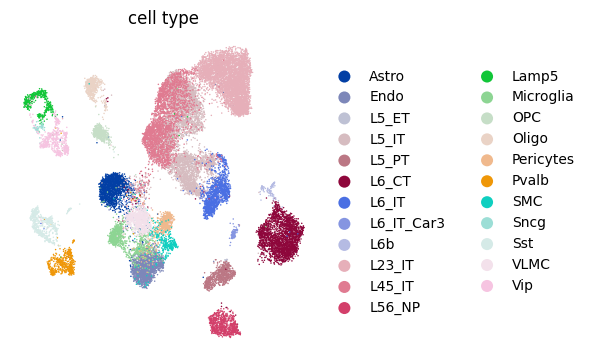

In [115]:
sc.pp.neighbors(adata_combined, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_combined)
sc.pl.scatter(adata_combined, basis='umap', color=['cell_type'], frameon=False)

In [116]:
raw_ad=sc.AnnData(adata_combined.X)
raw_ad.obs_names, raw_ad.var_names=adata_combined.obs_names, adata_combined.var_names
adata_combined.raw=raw_ad
sc.pp.highly_variable_genes(adata_combined, n_top_genes=1500)


In [117]:
sc.pp.pca(adata_combined, n_comps=50, use_highly_variable=True)

## Applying Seacells

In [130]:
#Construct kernel matrix

n_SEACells=100 
build_kernel_on='X_pca'
n_waypoint_eigs=10

In [131]:
model= SEACells.core.SEACells(adata_combined, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              n_waypoint_eigs=n_waypoint_eigs,
                              convergence_epsilon=1e-5
                              )

Welcome to SEACells!


In [132]:
model.construct_kernel_matrix()
M=model.kernel_matrix

Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/25932 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/25932 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/25932 [00:00<?, ?it/s]

Constructing CSR matrix...


In [133]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 96 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 14/14 [00:00<00:00, 50.52it/s]

Selecting 4 cells from greedy initialization.


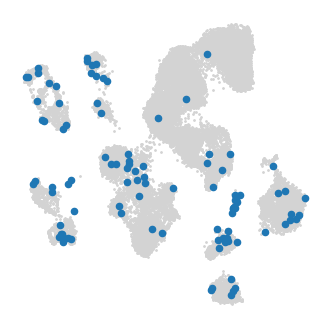

In [134]:
SEACells.plot.plot_initialization(adata_combined, model)

In [136]:
model.fit(min_iter=10, max_iter=30)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
Setting convergence threshold at 0.00287
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.
Converged after 20 iterations.
Ran for 21 iterations


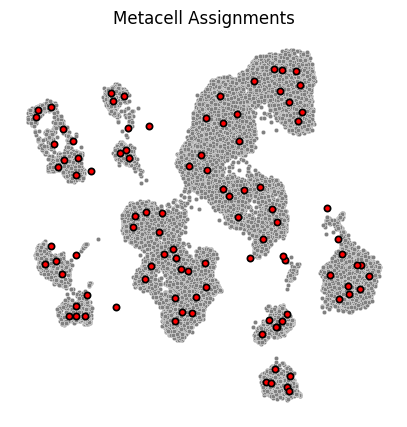

In [137]:
SEACells.plot.plot_2D(adata_combined, colour_metacells=False)

## METACELL PLOT FOR ENVI LATENT COMBINED

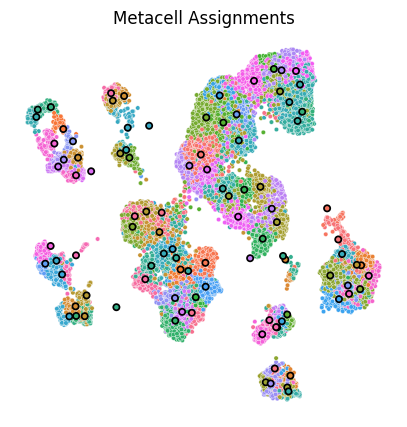

In [138]:
SEACells.plot.plot_2D(adata_combined, colour_metacells=True)

## Infering Metacells using metacells 2

In [143]:
import metacells as mc
import scanpy as sc
"""
Cross-Similarity
----------------
"""
#

from __future__ import annotations
from typing import TYPE_CHECKING
from warnings import warn
import logging
import os
import warnings
import datetime

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # FATA

warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.FATAL)
logging.getLogger('tensorflow_probability').setLevel(logging.FATAL)

from IPython.display import clear_output


import numpy as np
import pandas as pd
import scanpy as sc
import colorcet
import sklearn.neighbors
import scipy.sparse
import numpy as np
#from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from typing import Optional
from typing import Union
import numpy as np
import pandas as pd
from anndata import AnnData  # type: ignore
from numpy.typing import NDArray
import umap.umap_ as umap
import matplotlib
import matplotlib.pyplot as plt
import colorcet
import sklearn.neighbors
       # Plotting ENVI latent and COVET matrices
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse

import metacells.parameters as pr
import metacells.utilities as ut
from scipy.sparse import load_npz


In [ ]:
print(f"Min: {np.min(adata_combined.X)}, Max: {np.max(adata_combined.X)}")
adata_combined.X = np.clip(adata_combined.X, a_min=0, a_max=None)
print(f"Min: {np.min(adata_combined.X)}, Max: {np.max(adata_combined.X)}")
zero_var_genes = np.sum(adata_combined.X, axis=0) == 0
print(f"Number of genes with zero counts: {np.sum(zero_var_genes)}")
sc.pp.highly_variable_genes(adata_combined, flavor="seurat_v3", n_top_genes=2000)
selected_genes = adata_combined.var["highly_variable"].values
print(f"Total genes selected: {np.sum(selected_genes)} / {len(selected_genes)}")
#lmao all got selected
#abhi ke liye lets move on 
adata_filtered = adata_combined[:, selected_genes].copy()
adata_filtered.var["lateral_gene"] = np.zeros(adata_filtered.n_vars, dtype=bool)


Min: -5.456294536590576, Max: 5.424695014953613


In [ ]:
mc.pl.divide_and_conquer_pipeline(adata_filtered, random_seed=123456)
print(adata_filtered.obs["metacell"])


set unnamed.var[rare_gene]: 0 true (0%) out of 512 bools
set unnamed.var[rare_gene_module]: 512 int32 elements with all outliers (100%)
set unnamed.obs[cells_rare_gene_module]: 25932 int32 elements with all outliers (100%)
set unnamed.obs[rare_cell]: 0 true (0%) out of 25932 bools
set unnamed.var[selected_gene]: 7 true (1.367%) out of 512 bools
set unnamed.obs[metacell]: 25932 int32s
set unnamed.obs[dissolved]: 0 true (0%) out of 25932 bools
set unnamed.obs[metacell_level]: 25932 int32s


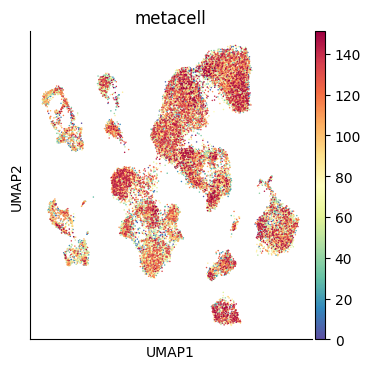

In [39]:
sc.tl.umap(adata_filtered)
sc.pl.umap(adata_filtered, color="metacell")


In [40]:
adata_filtered.obs["metacell"].value_counts()


metacell
28     194
60     194
71     193
61     193
114    193
      ... 
124    116
150    115
123    115
55     115
12     115
Name: count, Length: 152, dtype: int64

## Gdata contains metacells

In [46]:
gdata = mc.pl.collect_metacells(adata_filtered, random_seed=42)


set metacells.obs[grouped]: 152 int64s
set metacells.obs[total_umis]: 152 int64s
set metacells.layers[total_umis]: ndarray 152 X 512 float32s
set metacells.obs[__zeros_downsample_umis]: 152 int64s
set metacells.layers[zeros]: ndarray 152 X 512 int32s
set unnamed.obs[metacell_name]: 25932 <U8s
set metacells.var[highly_variable]: 512 true (100%) out of 512 bools
set metacells.var[means]: 512 float64s
set metacells.var[dispersions]: 512 float64s
set metacells.var[dispersions_norm]: 512 float32s
set metacells.var[highly_variable_rank]: 512 float32s
set metacells.var[variances]: 512 float64s
set metacells.var[variances_norm]: 512 float64s
set metacells.var[selected_gene]: 7 true (1.367%) out of 512 bools
set metacells.var[rare_gene]: 0 true (0%) out of 512 bools
set metacells.var[rare_gene_module]: 512 int32s
set metacells.var[lateral_gene]: 0 true (0%) out of 512 bools
set metacells.obs[metacells_rare_gene_module]: 152 int32s
set metacells.obs[rare_metacell]: 0 true (0%) out of 152 bools
s

In [47]:
gdata

AnnData object with n_obs × n_vars = 152 × 512
    obs: 'grouped', 'total_umis', '__zeros_downsample_umis', 'metacells_rare_gene_module', 'rare_metacell'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_rank', 'variances', 'variances_norm', 'selected_gene', 'rare_gene', 'rare_gene_module', 'lateral_gene'
    uns: '__name__', 'outliers', 'metacells_algorithm'
    layers: 'total_umis', 'zeros'

In [50]:
mc.pl.mcview.compute_for_mcview( adata= adata_filtered, gdata= gdata, random_seed=42)

set metacells.uns[mcview_format]: 1.0
set metacells.uns[outliers]: 0
set metacells.var[marker_gene]: 471 true (91.99%) out of 512 bools
set metacells.obsp[obs_balanced_ranks]: 1746 nonzero (7.557%) out of 23104 elements
set metacells.obsp[obs_pruned_ranks]: 610 nonzero (2.64%) out of 23104 elements
set metacells.obsp[obs_outgoing_weights]: 610 nonzero (2.64%) out of 23104 elements
set metacells.obsp[umap_distances]: csr_matrix 152 X 152 float32s (22952 > 0, 99.34%)
set metacells.obs[u]: 152 float32s
set metacells.obs[v]: 152 float32s
set metacells.obs[w]: 152 float32s
set metacells.obsp[obs_balanced_ranks]: 1746 nonzero (7.557%) out of 23104 elements
set metacells.obsp[obs_pruned_ranks]: 610 nonzero (2.64%) out of 23104 elements
set metacells.obsp[obs_outgoing_weights]: 610 nonzero (2.64%) out of 23104 elements
set metacells.obsp[umap_distances]: csr_matrix 152 X 152 float32s (22952 > 0, 99.34%)
set metacells.obs[x]: 152 float32s
set metacells.obs[y]: 152 float32s
set unnamed.obs[most_

In [52]:
adata_filtered.write("adata_filtered.h5ad")
gdata.write("gdata.h5ad")


## Using this file in MCView , this is what i get 




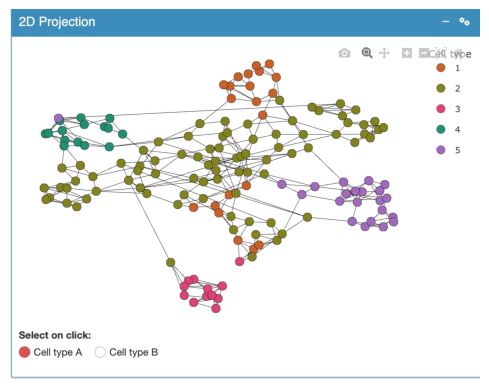

In [1]:
import matplotlib.pyplot as plt
import os


image_path = "/Users/anushka/Documents/Undergraduate-Project/McView/mcview_graph_envi_latent.jpeg"
img = plt.imread(image_path)  
plt.imshow(img) 
plt.axis("off")  
plt.show()  



## More analysis 

In [62]:
gdata

AnnData object with n_obs × n_vars = 152 × 512
    obs: 'grouped', 'total_umis', '__zeros_downsample_umis', 'metacells_rare_gene_module', 'rare_metacell', 'u', 'v', 'w', 'x', 'y', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_rank', 'variances', 'variances_norm', 'selected_gene', 'rare_gene', 'rare_gene_module', 'lateral_gene', 'marker_gene', 'significant_inner_folds_count'
    uns: '__name__', 'outliers', 'metacells_algorithm', 'mcview_format', 'pca', 'neighbors', 'leiden', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'total_umis', 'zeros', 'inner_fold', 'inner_stdev_log'
    obsp: 'obs_balanced_ranks', 'obs_pruned_ranks', 'obs_outgoing_weights', 'umap_distances', 'distances', 'connectivities'
    varp: 'var_similarity'

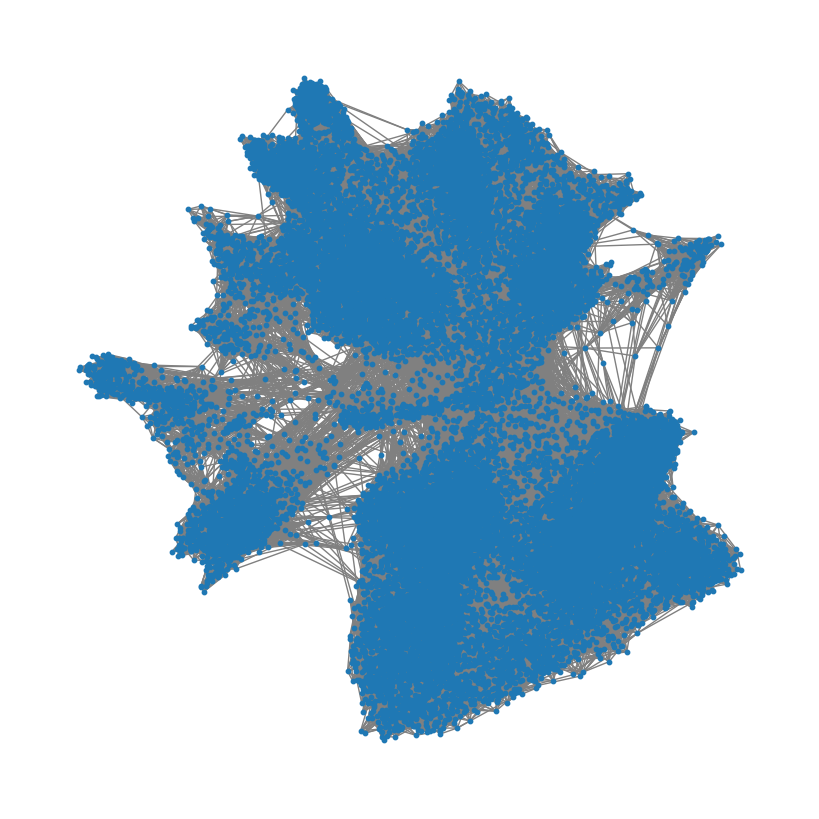

In [61]:
import scanpy as sc

# Compute neighbors if missing
if "neighbors" not in adata_filtered.uns:
    sc.pp.neighbors(adata_filtered)  # Creates a KNN graph for single-cell data

# Convert adjacency matrix into a NetworkX graph
import networkx as nx
import scipy.sparse

adj_matrix = adata_filtered.obsp["connectivities"]  # Get adjacency matrix
G = nx.from_scipy_sparse_array(adj_matrix)  # Convert to NetworkX graph

# Plot the network
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
nx.draw(G, node_size=10, edge_color="gray")
plt.show()


## I am basically trying to create a network graph of the metacells i found through gdata

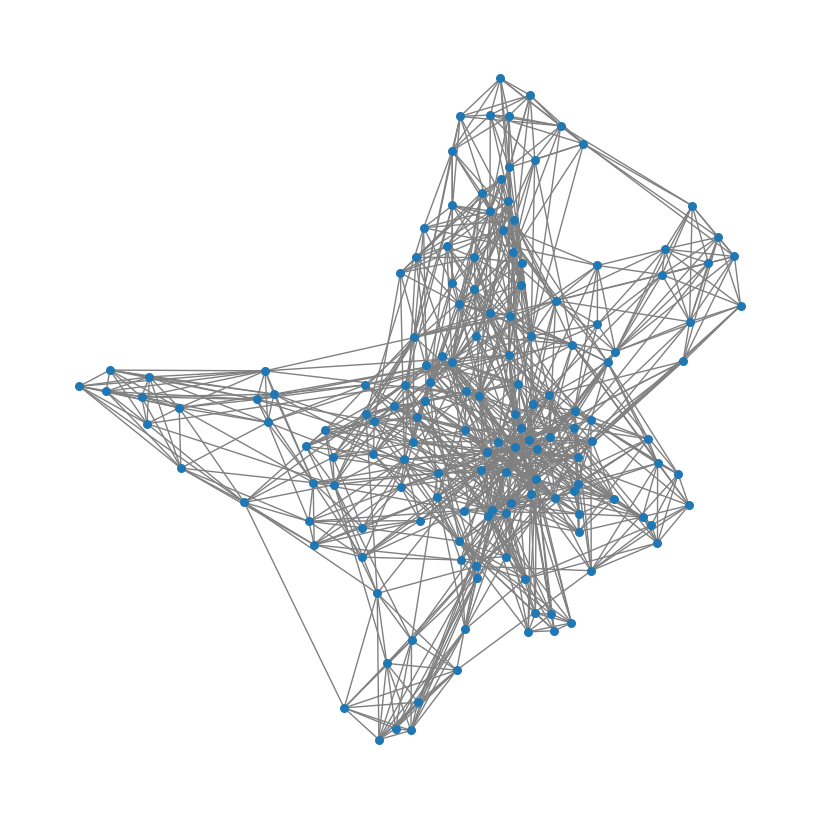

In [68]:
import scanpy as sc

# Compute neighbors if missing
if "neighbors" not in gdata.uns:
    sc.pp.neighbors(gdata)  # Creates a KNN graph for single-cell data


adj_matrix_g = gdata.obsp["connectivities"]  # Get adjacency matrix
G = nx.from_scipy_sparse_array(adj_matrix_g)  # Convert to NetworkX graph

# Plot the network
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
nx.draw(G, node_size=30, edge_color="grey")
plt.show()


In [71]:
# Extract UMAP coordinates
sc_coords = adata_filtered.obsm["X_umap"]  # Single-cell UMAP
mc_coords = gdata.obsm["X_umap"]  # Metacell UMAP

# Tried creating a umap of metacells overlapped with single cells. which clearly did not work out. Seacells graph is the best uptil now

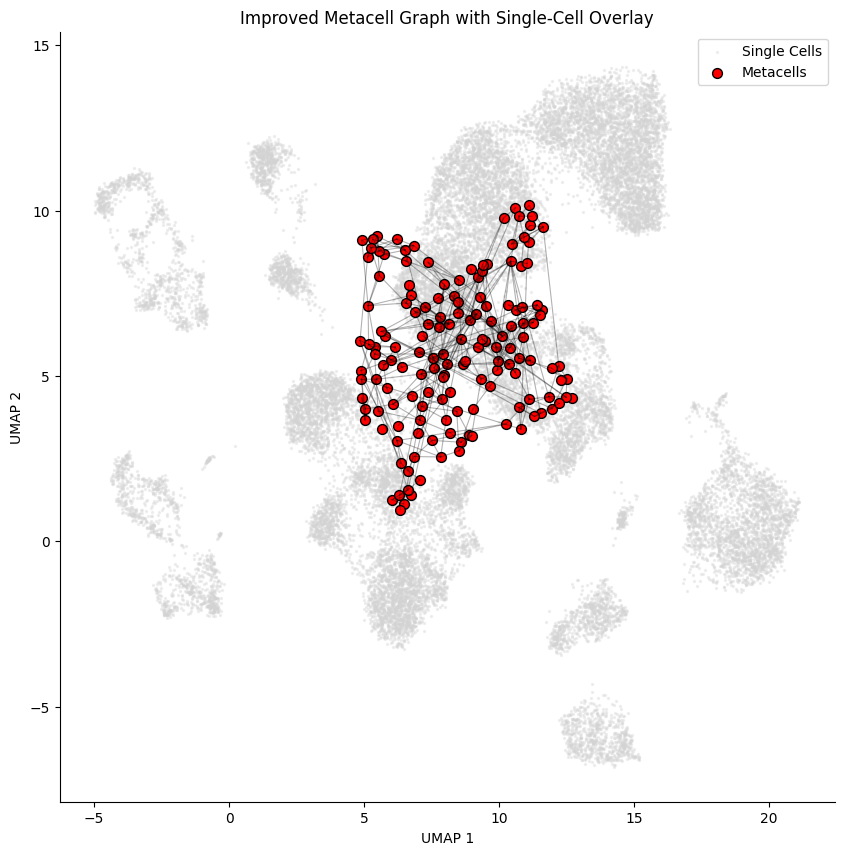

In [74]:
plt.figure(figsize=(10, 10))
plt.scatter(sc_coords[:, 0], sc_coords[:, 1], c="lightgray", s=2, alpha=0.3, label="Single Cells")
plt.scatter(mc_coords[:, 0], mc_coords[:, 1], c="red", s=50, edgecolors="black", label="Metacells")

# Step 4: Reduce edges drawn
for i, j in G.edges():
    if np.random.rand() < 0.3:  # Only draw 30% of edges to avoid overplotting
        plt.plot([mc_coords[i, 0], mc_coords[j, 0]], 
                 [mc_coords[i, 1], mc_coords[j, 1]], 
                 "k-", alpha=0.3, linewidth=0.8)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.title("Improved Metacell Graph with Single-Cell Overlay")
plt.show()